This notebook creates a pool of starting positions/states used to initialize episodes and match realistic starting conditions. After frame 0, the policy and discriminator take over.

### Initial Position Pool

In [1]:
# mount + imports
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Master-Thesis/notebooks/16-32-prey')
sys.path.insert(0, '/content/drive/MyDrive/Master-Thesis/notebooks/16-32-prey')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# pip install
!pip install ultralytics
!pip install deep-sort-realtime

In [7]:
# import necessary libraries
import os, json, glob, pickle
import numpy as np, torch, cv2
from pathlib import Path
from utils.dataset_utils import (find_valid_windows, extract_windows, get_expert_tensors, scale_data, hungarian_assign, get_velocity)
import matplotlib.pyplot as plt

# define paths
arena = 2160.0
base = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing')
FF = base / 'Processed/video/expert_tensors/32_prey_interactions/2. filtered_frames'
INTERACTION_16 = base / 'Raw/pred_prey_interaction/pred_prey_interaction_16'
INTERACTION_32 = base / 'Raw/pred_prey_interaction/pred_prey_interaction_32'
ATTACK_16 = base / 'Raw/pred_attack/pred_attack_16'
ATTACK_32 = base / 'Raw/pred_attack/pred_attack_32'
output = base / 'Processed/init_pool'
window_len = 10

In [8]:
# build intial pred-prey configurations from 16-prey attacks, 32-prey attacks, and the 16-prey interactions hand-labeled clips
def build_hl_coordinates(json_dir, n_prey_expected):

    # store frame configs from all JSON files
    pools = []

    # iterate over all JSON files
    for path in sorted(glob.glob(str(json_dir / '*.json'))):

        # load label studio annotation file
        with open(path, "r") as f:
            data = json.load(f)

        # read image dimensions from first annotation
        r0 = data[0]["annotations"][0]["result"][0]

        # calculate scaling factors for the axes
        scale = np.array([
            arena / r0["original_width"],
            arena / r0["original_height"]
        ])

        # convert annnotations of every frame to ararys
        pairs  = [scale_data(pts) for pts in data]

        # assign pred detections over time
        pred_o = hungarian_assign([
            predator_points * scale
            for predator_points, _ in pairs
        ])

        # assign prey detections over time
        prey_o = hungarian_assign([
            prey_points * scale
            for _, prey_points in pairs
        ])

        # discard clips w/o expected number of prey
        if prey_o.shape[1] != n_prey_expected:
            print(f"  skip {os.path.basename(path)}: {prey_o.shape[1]} prey")
            continue

        # calculate velocity vectors
        pv, qv = get_velocity(pred_o), get_velocity(prey_o)

        # process each frame
        frames = []
        for t in range(pv.shape[0]):
            xs = np.concatenate([pred_o[t, :, 0], prey_o[t, :, 0]])
            ys = np.concatenate([pred_o[t, :, 1], prey_o[t, :, 1]])
            vx = np.concatenate([pv[t, :, 0],     qv[t, :, 0]])
            vy = np.concatenate([pv[t, :, 1],     qv[t, :, 1]])
            headings = np.arctan2(vy, vx)
            frames.append(np.stack([xs, ys, headings], axis=-1))

        clip_tensor = torch.tensor(np.stack(frames), dtype=torch.float32)
        pools.append(clip_tensor)

        # report number of configs extracted
        print(
            f"  {os.path.basename(path):<30s} "
            f"+{len(frames)}"
        )

    return torch.cat(pools, 0) if pools else torch.empty(0)

In [9]:
# build intial pred-prey configurations from the 32-prey interaction videos
def build_video_coordinates(video_dir, total_detections, window_len=window_len):

    # store first frame of every valid temporal window
    pools = []

    # iterate over filter frame files
    for fname in sorted(os.listdir(FF)):
        if not fname.startswith("filtered_frames_"):
            continue

        # get corresponding video filenames
        video = fname[len("filtered_frames_"):-len(".pkl")]

        # open corresponding video + get metadata
        cap = cv2.VideoCapture(str(video_dir / video))
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        if width == 0 or height == 0:
            continue

        # load filtered detections for current videos
        with open(FF / fname, "rb") as f:
            filtered = pickle.load(f)

        episodes = find_valid_windows(filtered, window_len=window_len,
                                      total_detections=total_detections)

        # convert valid episode intervals into explicit frame windows
        windows  = extract_windows(episodes, window_len=window_len)
        if not windows:
            continue

        # convert filtered detections into expert tensors
        _, _, coords = get_expert_tensors(filtered, windows, width, height,
                                          max_speed=25.0 * width / arena,
                                          window_size=window_len)

        # keep first frame of each window
        coords = coords[:, 0, :, :].clone()

        # normalize to arena
        coords[..., 0] *= arena
        coords[..., 1] *= arena

        # add initial configurations to the pool
        pools.append(coords)
        print(f"  {video:<34s} {width}x{height}  +{len(coords)}")

    return torch.cat(pools, 0) if pools else torch.empty(0)

In [10]:
print("32 prey interaction (video):")
interaction_32 = build_video_coordinates(INTERACTION_32, total_detections=33)

print("\n16 prey interaction (JSON):")
interaction_16 = build_hl_coordinates(INTERACTION_16, n_prey_expected=16)

print("\n32 prey attack (JSON):")
attack_32 = build_hl_coordinates(ATTACK_32, n_prey_expected=32)

print("\n16 prey attack (JSON):")
attack_16 = build_hl_coordinates(ATTACK_16, n_prey_expected=16)

# combine configs with matching object counts
init_pool_16 = torch.cat([interaction_16, attack_16], 0)
init_pool_32 = torch.cat([interaction_32, attack_32], 0)
print(f"\n16-prey: {len(interaction_16)} interaction + {len(attack_16)} attack = {tuple(init_pool_16.shape)}")
print(f"32-prey: {len(interaction_32)} interaction + {len(attack_32)} attack = {tuple(init_pool_32.shape)}")

# validate expected dimensions
assert init_pool_16.shape[1:] == (17, 3)
assert init_pool_32.shape[1:] == (33, 3)

# validate that all values are finite
assert torch.isfinite(init_pool_16).all()
assert torch.isfinite(init_pool_32).all()

# validate x/y coordinate ranges
for n, pool in [
    ("16", init_pool_16),
    ("32", init_pool_32)
]:
    xy = pool[..., :2]

    print(
        f"{n}-prey xy range: "
        f"{xy.min():.1f} .. {xy.max():.1f} "
        f"(arena is 0 .. {arena:.0f})"
    )

    assert xy.min() >= 0
    assert xy.max() <= arena

output.mkdir(parents=True, exist_ok=True)
torch.save(init_pool_16, output / 'init_pool_16prey.pt')
torch.save(init_pool_32, output / 'init_pool_32prey.pt')
print("saved")

32 prey interaction (video):
  pred_prey_interaction_16.02.mp4    2160x2160  +5
  pred_prey_interaction_2.49.mp4     2160x2160  +9
  pred_prey_interaction_3.00.mp4     2160x2160  +1
  pred_prey_interaction_3.11.mp4     2160x2160  +2
  pred_prey_interaction_3.31.mp4     2160x2160  +1
  pred_prey_interaction_3.33.mp4     2160x2160  +1
  pred_prey_interaction_3.59.mp4     2160x2160  +3
  pred_prey_interaction_4.17.mp4     2160x2160  +2

16 prey interaction (JSON):
  pred_prey_interaction_11_16.json +374
  pred_prey_interaction_1_16.json +124
  pred_prey_interaction_2_16.json +187
  pred_prey_interaction_3_16.json +374
  pred_prey_interaction_4_16.json +187
  pred_prey_interaction_5_16.json +187
  pred_prey_interaction_6_16.json +62
  pred_prey_interaction_7_16.json +124

32 prey attack (JSON):
  pred_attack_1.json             +34
  pred_attack_10.json            +29
  pred_attack_11.json            +25
  pred_attack_12.json            +38
  pred_attack_13.json            +19
  pred_attack

Initial Position Visualizations:

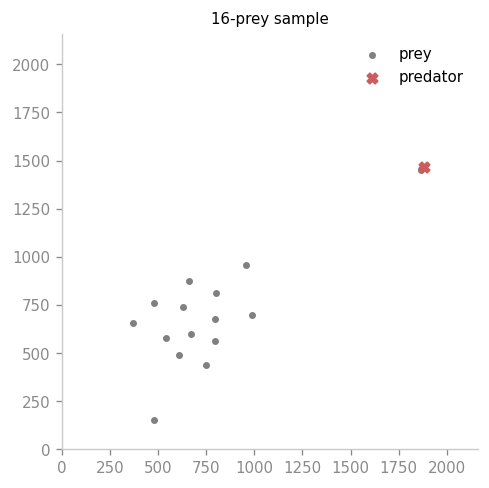

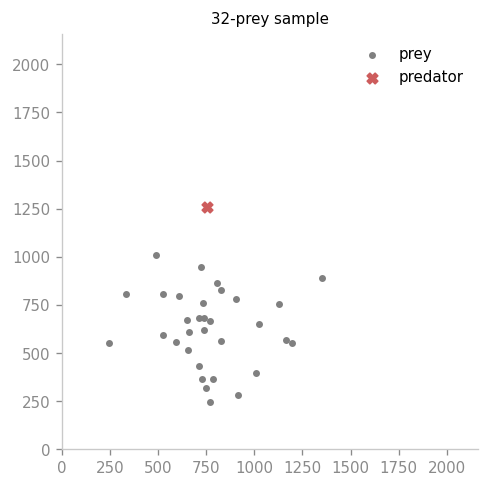

In [47]:
def plot_sample(pool, title):

    # no sampling from empty pool
    if len(pool) == 0:
        print(f"Cannot plot {title}: pool is empty")
        return

    # select random configuration
    idx = torch.randint(0, len(pool), (1,)).item()
    s = pool[idx]

    plt.figure(figsize=(4.5, 4.5))

    # prey
    plt.scatter(s[1:, 0], s[1:, 1], c="grey", s=10, label="prey")

    # predator
    plt.scatter(s[0, 0], s[0, 1], c="indianred", marker="X", s=40, label="predator")

    plt.xlim(0, arena)
    plt.ylim(0, arena)
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.legend()
    plt.show()

plot_sample(init_pool_16, "16-prey sample")
plot_sample(init_pool_32, "32-prey sample")

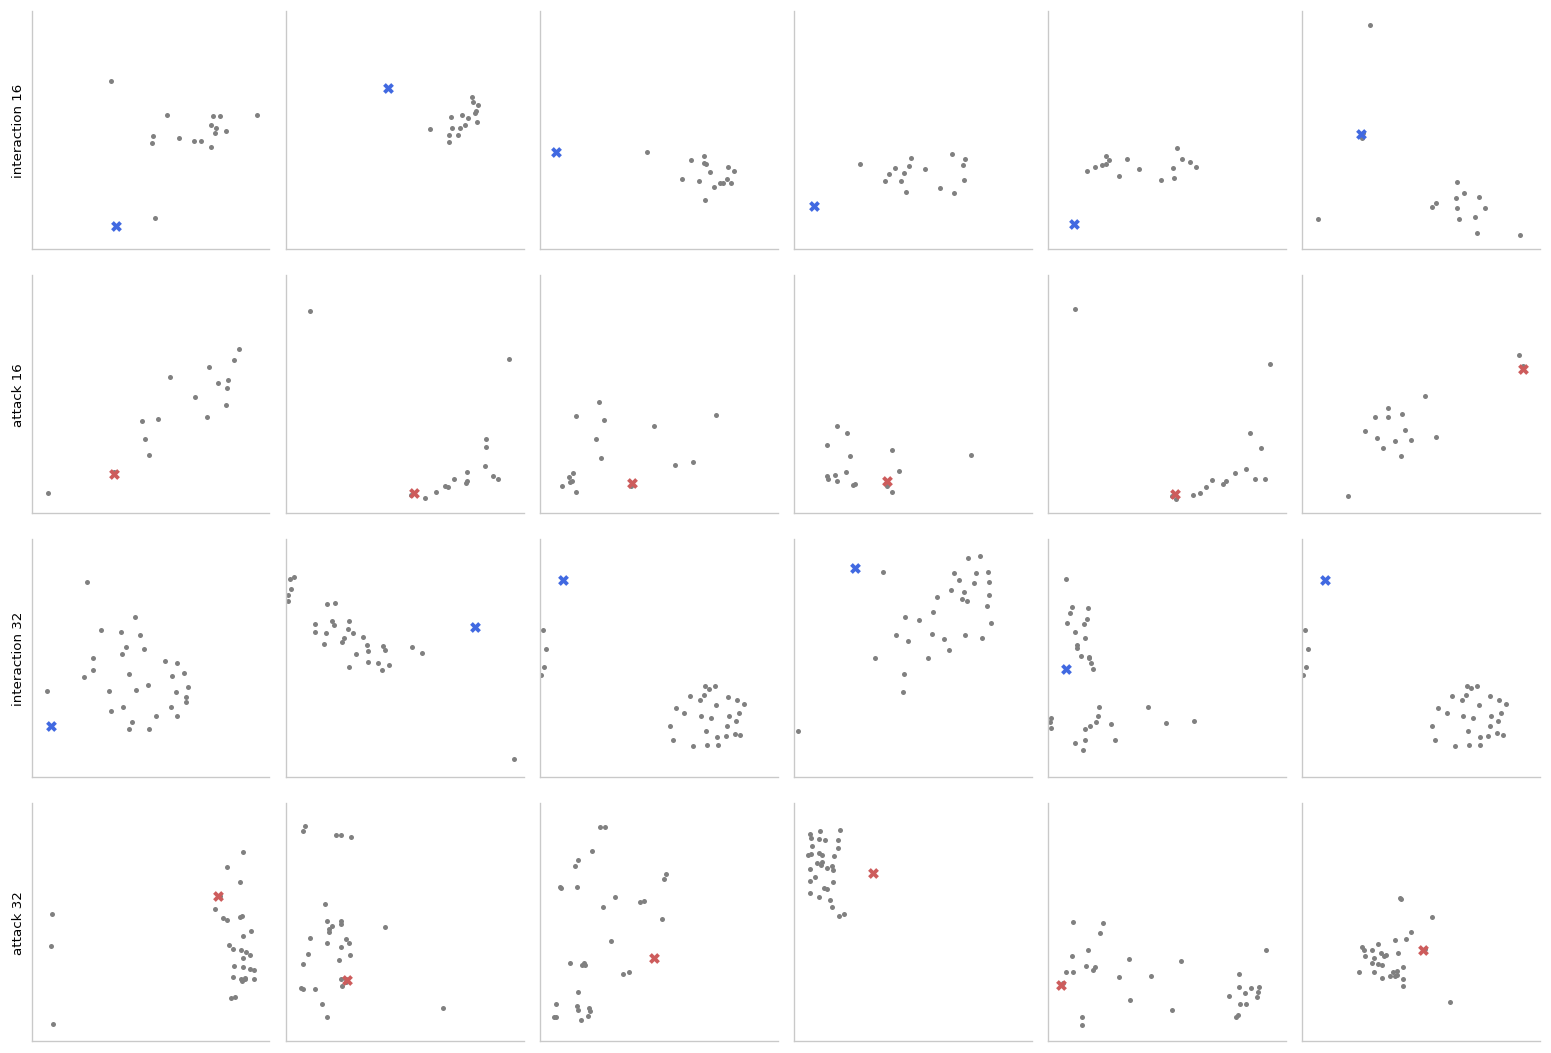

In [44]:
datasets = [
    ("interaction 16", interaction_16, "royalblue"),
    ("attack 16",      attack_16,      "indianred"),
    ("interaction 32", interaction_32, "royalblue"),
    ("attack 32",      attack_32,      "indianred"),
    ]

# 4 row, 6 column
fig, axes = plt.subplots(4, 6, figsize=(13, 9))

# process one dataset per row
for row, (name, pool, predator_color) in enumerate(datasets):

    # select at most six random configurations
    n_samples = min(6, len(pool))
    indices = torch.randperm(len(pool))[:n_samples]

    # draw the selected configurations
    for j in range(6):
        ax = axes[row, j]

        # remove ticks from every subplot
        ax.set_xticks([])
        ax.set_yticks([])

        # select one initial predator-prey configuration
        sample = pool[indices[j]]

        # prey
        ax.scatter(sample[1:, 0], sample[1:, 1], s=9, color="gray", linewidths=0)

        # predator
        ax.scatter(sample[0, 0], sample[0, 1], s=42, color=predator_color, marker="X", linewidths=0)

        # arena
        ax.set_xlim(0, arena)
        ax.set_ylim(0, arena)
        ax.set_aspect("equal")

        # add dataset label
        if j == 0:
            ax.set_ylabel(name, color="black", fontsize=8)

plt.tight_layout()
plt.show()